# Rashomon effect

- Many different models can explain the same dataset **equally well**.
- However, these models may rely on **different patterns or features** in the data.
- This phenomenon is known as the **Rashomon effect**.

In this notebook, we study the setting where we have multiple models $\{\widehat{f}_b\}_{b=1}^B$ and we want to understand how to aggregate their information.

There are two main approaches:

- **Ensemble approach**: aggregate the models first, then compute feature importance
$$
\widehat{\psi}^{\mathrm{ens}}
=
\psi\!\left(\frac{1}{B}\sum_{b=1}^{B} \widehat{f}_b\right)
$$

- **Sub-model approach**: compute importances per model first, then aggregate them
$$
\widehat{\psi}^{\mathrm{sub}}
=
\frac{1}{B}\sum_{b=1}^{B} \psi(\widehat{f}_b)
$$

We use **Leave-One-Covariate-Out ($\psi_\mathrm{LOCO}$)** importance throughout this notebook.

### Friedman

We use the Friedman1 Data Generation Process, defined as:
$$
Y = 10 \sin(\pi X^0 X^1) + 20 (X^2 - 0.5)^2 + 10 X^3 + 5 X^4 + \varepsilon,\quad \varepsilon \sim \mathcal{N}(0, 1).
$$

In [1]:
from sklearn.datasets import make_friedman1
import numpy as np
from sklearn.model_selection import train_test_split

# Parameters
n_features = 10
n_samples = 512
n_ensemble = 10
noise = 1
random_state = 0

X, y = make_friedman1(
    n_samples=n_samples,
    n_features=n_features,
    noise=noise,
    random_state=random_state,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=random_state
)

/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


We start by training an ensemble regressor using `VotingRegressor`.

In [2]:
from sklearn.ensemble import VotingRegressor
from sklearn.neural_network import MLPRegressor

model = VotingRegressor(
    [
        (
            f"mlp_{i}",
            MLPRegressor(
                hidden_layer_sizes=(64, 32, 8),
                max_iter=500,
                random_state=i + random_state,
                early_stopping=True,
            ),
        )
        for i in range(n_ensemble)
    ]
)

model.fit(X_train, y_train)

/home/areyerol/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('mlp_0', ...), ('mlp_1', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'


We evaluate the performance of the ensemble model and of the individual sub-models.

In [3]:
sub_model_scores = []
for sub_model in model.estimators_:
    sub_model_scores.append(sub_model.score(X_test, y_test))

print(f"Ensemble R^2 score: {model.score(X_test, y_test):.3f}")
print(
    f"Sub-model R^2 scores: {np.mean(sub_model_scores):.3f} ± {np.std(sub_model_scores):.3f}"
)

Ensemble R^2 score: 0.655
Sub-model R^2 scores: 0.546 ± 0.269


Note that with a simple, transparent model we would not be able to achieve such accuracy. Therefore, model-agnostic Variable Importance Measures are necessary to obtain both good predictive performance and meaningful interpretability.

We estimate the LOCO importance using both approaches: sub-models and the ensemble.

In [4]:
from hidimstat import LOCO
from tqdm import tqdm
from sklearn.metrics import mean_squared_error


n_jobs = 5
loco = LOCO(estimator=model, n_jobs=n_jobs)
loco.fit(X_train, y_train)

importances_sub_models_list = []

# Sub-model importance scores
for ensemble_idx in range(n_ensemble):
    importance_tmp = []
    for j in tqdm(range(n_features)):
        sub_model = model.estimators_[ensemble_idx]
        sub_model_j = loco._list_estimators[j].estimators_[ensemble_idx]
        loss_ref = mean_squared_error(y_test, sub_model.predict(X_test))
        loss_j = mean_squared_error(
            y_test, sub_model_j.predict(np.delete(X_test, j, axis=1))
        )
        importance_tmp.append(loss_j - loss_ref)
    importances_sub_models_list.append(importance_tmp)
importance_sub_models = np.array(importances_sub_models_list)

# Ensemble importance scores
importance_ensemble_list = []
for j in tqdm(range(n_features)):
    loss_ref = mean_squared_error(y_test, model.predict(X_test))
    loss_j = mean_squared_error(
        y_test, loco._list_estimators[j].predict(np.delete(X_test, j, axis=1))
    )
    importance_ensemble_list.append(loss_j - loss_ref)
importance_ensemble = np.array(importance_ensemble_list)

/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/areyerol/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check imp

## Compare the performance of both approaches

The ultimate goal is to estimate the Total Sobol' index, defined as:
$$
\psi_{\mathrm{TSI}}(j)
=
\mathbb{E}\big[\ell(m_{-j}^\star(X^{-j}), Y)\big]
-
\mathbb{E}\big[\ell(m^\star(X), Y)\big].
$$

To compare both strategies, we can study the mean squared error of the estimator:
$$
\mathbb{E}\big[(\hat{\psi}(j) - \psi_{\mathrm{TSI}}(j))^2\big].
$$

The challenge is that the true target quantity $\psi_{\mathrm{TSI}}(j)$ is unknown.

However, since we know the underlying data-generating distribution and can sample from it, we can approximate it by generating a very large dataset to obtain an accurate estimate of the target quantity.

We then sample a large dataset, train a model, and compute the LOCO importance using this fitted model.

In [5]:
X_asymp, y_asymp = make_friedman1(
    n_samples=10000,
    n_features=n_features,
    random_state=random_state,
    noise=noise,
)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_asymp, y_asymp, random_state=random_state
)
model_a = MLPRegressor(
    hidden_layer_sizes=(64, 32, 8),
    max_iter=500,
    random_state=random_state,
    early_stopping=True,
)
model_a.fit(X_train_a, y_train_a)
print(f"R^2 score: {model_a.score(X_test_a, y_test_a):.3f}")
loco = LOCO(estimator=model_a, n_jobs=n_jobs)
loco.fit(X_train_a, y_train_a)
importance_asymptotic_list = []

for j in tqdm(range(n_features)):
    loss_ref = mean_squared_error(y_test_a, model_a.predict(X_test_a))
    loss_j = mean_squared_error(
        y_test_a,
        loco._list_estimators[j].predict(np.delete(X_test_a, j, axis=1)),
    )
    importance_asymptotic_list.append(loss_j - loss_ref)
importance_asymptotic = np.array(importance_asymptotic_list)

R^2 score: 0.953


100%|██████████| 10/10 [00:00<00:00, 72.46it/s]


With this asymptotic importance, we can compute the MSE of both approaches: sub-models and ensemble.

In [6]:
mse_sub_models = mean_squared_error(
    importance_sub_models.mean(axis=0), importance_asymptotic
)
mse_ensemble = mean_squared_error(importance_ensemble, importance_asymptotic)

print(f"MSE of sub-model importance: {mse_sub_models:.3f}")
print(f"MSE of ensemble importance: {mse_ensemble:.3f}")

MSE of sub-model importance: 14.404
MSE of ensemble importance: 9.144


We can also visualize the estimated importance of each feature, coordinate by coordinate.

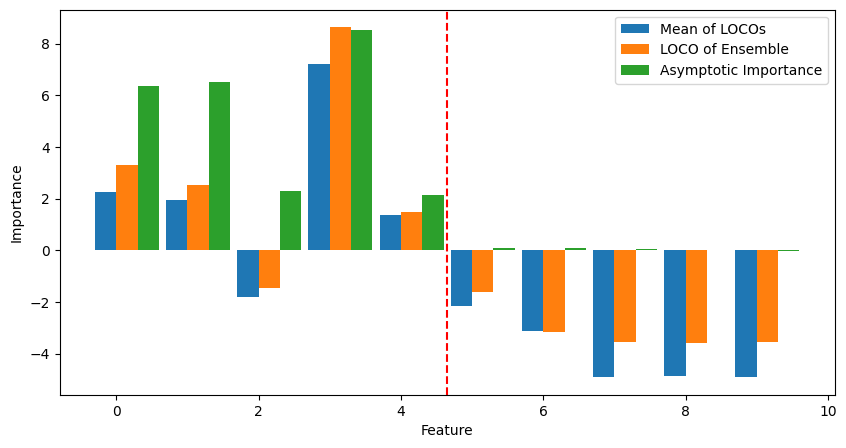

In [7]:
import matplotlib.pyplot as plt

features = np.arange(X.shape[1])

plt.figure(figsize=(10, 5))

plt.bar(
    features - 0.15,
    importance_sub_models.mean(axis=0),
    width=0.3,
    label="Mean of LOCOs",
)

plt.bar(
    features + 0.15,
    importance_ensemble,
    width=0.3,
    label="LOCO of Ensemble",
)
plt.bar(
    features + 0.45,
    importance_asymptotic,
    width=0.3,
    label="Asymptotic Importance",
)

plt.axvline(4.65, color="red", ls="--")

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.legend()

plt.show()

We observe a clear gain from using the ensemble approach rather than sub-models with LOCO. Similar conclusions can be drawn for Shapley Additive Global Explanations (SAGE), which are based on Shapley values for global explanations, as well as for marginalization-based approaches such as Sobol-CFI or SAGE value functions.

The gains are typically less pronounced for Conditional Feature Importance (CFI) and Permutation Feature Importance (PFI).

For more details, see:

Joseph Paillard, Angel Reyero Lobo, Denis A. Engemann, and Bertrand Thirion. *Aggregate models, not explanations: Improving feature importance estimation*. International Conference on Machine Learning (ICML), 2026.